# Supplementary McFaline UMAP coverage

Reproduces the McFaline UMAP coverage plot.


In [1]:
# Set to True to write image files to figures/supplement/output/.
SAVE_FIGURES = False

## UMAP coverage analysis


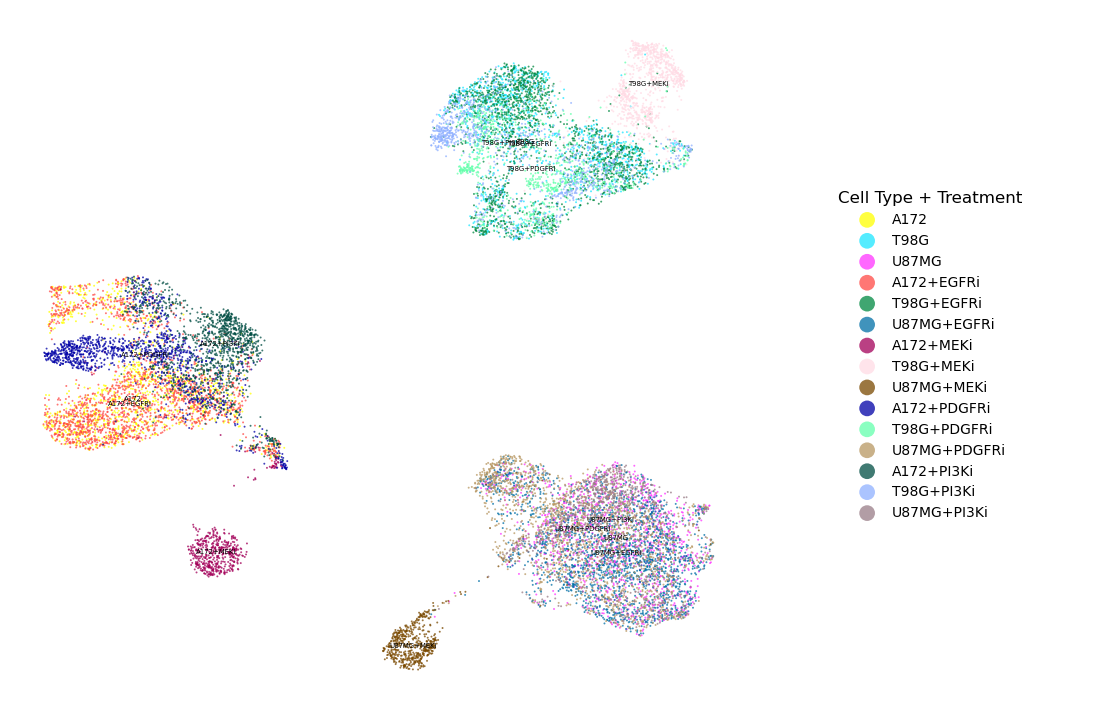

In [2]:
import os
os.environ.setdefault("KMP_WARNINGS", "FALSE")
import importlib
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

RAW_DIR = "data/mcfaline/raw"
PROCESSED_DIR = "data/mcfaline/processed"
CACHE_PATH = os.path.join(PROCESSED_DIR, "mcfaline_ctrl_for_umap.h5ad")

########################################################
# Inline Settings
########################################################

N_NEIGHBORS = 15
N_PCS = 50
UMAP_MIN_DIST = 0.3
UMAP_SPREAD = 1.0

# PALETTE_NAME = "glasbey"
PALETTE_NAME = "scanpy"
# PALETTE_NAME = "tab20"
# PALETTE_NAME = "muted"
# PALETTE_NAME = "structured"

DOT_SIZE = 2
DOT_ALPHA = 0.75
SHOW_UMAP_TEXT_LABELS = True
UMAP_TEXT_FONTSIZE = 5

FIGSIZE = (11, 7)
FIG_DPI = 600
FIG_NAME = "supp_mcfaline_umap.png"

TREATMENT_RENAME_MAP = {
    "lapatinib": "EGFRi",
    "nintedanib": "PDGFRi",
    "trametinib": "MEKi",
    "zstk474": "PI3Ki",
    "none": "",
}


########################################################
# Helper Functions
########################################################

def adjust_color(color, amount):
    rgb = np.array(color[:3])
    return tuple(1 - (1 - rgb) * amount)


def make_covariate_series(cell_type_s, treatment_s):
    """Build CELLTYPE[+TREATMENT] strings (no trailing '+' when treatment is empty)."""
    cell = cell_type_s.astype(str).str.upper()
    treat = (
        treatment_s.astype(str)
        .map(TREATMENT_RENAME_MAP)
        .fillna(treatment_s.astype(str))
    )
    out = cell.where(treat == "", cell + "+" + treat)
    return out


def covariate_sort_key(covariate):
    if "+" in covariate:
        cell_type, treatment = covariate.split("+", 1)
    else:
        cell_type, treatment = covariate, ""
    return treatment, cell_type


def get_palette(unique_covariates):
    if PALETTE_NAME == "glasbey":
        try:
            glasbey = importlib.import_module("glasbey")
            return dict(zip(unique_covariates, glasbey.create_palette(len(unique_covariates))))
        except ImportError:
            print("Install glasbey with `pip install glasbey`; falling back to Scanpy default_102.")
            palette = sc.pl.palettes.default_102
            return {cv: palette[i % len(palette)] for i, cv in enumerate(unique_covariates)}

    if PALETTE_NAME == "scanpy":
        palette = sc.pl.palettes.default_102
    elif PALETTE_NAME == "tab20":
        palette = plt.get_cmap("tab20").colors
    elif PALETTE_NAME == "muted":
        palette = [
            "#4E79A7", "#A0CBE8", "#F28E2B", "#FFBE7D", "#59A14F", "#8CD17D",
            "#B6992D", "#F1CE63", "#499894", "#86BCB6", "#E15759", "#FF9D9A",
            "#79706E", "#BAB0AC", "#D37295", "#FABFD2", "#B07AA1", "#D4A6C8",
            "#9D7660", "#D7B5A6", "#6B6ECF", "#B5B5E6", "#637939", "#CEDB9C",
            "#8C6D31", "#E7CB94", "#843C39", "#D6616B", "#7B4173", "#CE6DBD",
        ]
    elif PALETTE_NAME == "structured":
        def _split(cv):
            return cv.split("+", 1) if "+" in cv else (cv, "")
        cell_types = sorted({_split(cv)[0] for cv in unique_covariates})
        treatments = sorted({_split(cv)[1] for cv in unique_covariates})
        base_palette = plt.get_cmap("tab10").colors
        shade_levels = np.linspace(0.45, 1.0, len(treatments))
        color_map = {}
        for i, cell_type in enumerate(cell_types):
            base_color = base_palette[i % len(base_palette)]
            for treatment, shade in zip(treatments, shade_levels):
                key = f"{cell_type}+{treatment}" if treatment else cell_type
                color_map[key] = adjust_color(base_color, shade)
        return color_map
    else:
        raise ValueError(f"Unknown PALETTE_NAME: {PALETTE_NAME}")

    return {cv: palette[i % len(palette)] for i, cv in enumerate(unique_covariates)}


def clean_axis(ax):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


########################################################
# Load Data (build ad_subset, cache for re-runs)
########################################################

if not os.path.exists(CACHE_PATH):
    obs_meta = pd.read_csv(os.path.join(RAW_DIR, "obs_meta.csv"), index_col=0)
    mask1 = obs_meta["perturbation"] == "control"
    mask2 = obs_meta["sample"] == "sci3_CRISPRi_kinome"
    mask3 = obs_meta["gRNA_id"].notna()
    cell_mask = (mask1 & mask2 & mask3).values

    mcfaline = sc.read_h5ad(os.path.join(PROCESSED_DIR, "mcfaline.h5ad"))
    gene_mask = mcfaline.var_names
    del mcfaline

    adata = sc.read_h5ad(
        os.path.join(RAW_DIR, "mcfaline23_gxe_processed.h5ad"), backed="r"
    )
    ad_subset = adata[cell_mask, gene_mask].to_memory()
    sc.pp.normalize_total(ad_subset)
    sc.pp.log1p(ad_subset)
    ad_subset.write_h5ad(CACHE_PATH)
else:
    ad_subset = sc.read_h5ad(CACHE_PATH)

ad_subset.obs["covariate"] = make_covariate_series(
    ad_subset.obs["cell_type"], ad_subset.obs["treatment"]
)


########################################################
# UMAP Coordinates
########################################################

sc.pp.scale(ad_subset, max_value=10)
sc.tl.pca(ad_subset, svd_solver="arpack")
sc.pp.neighbors(ad_subset, n_neighbors=N_NEIGHBORS, n_pcs=N_PCS)
sc.tl.umap(ad_subset, min_dist=UMAP_MIN_DIST, spread=UMAP_SPREAD)

umap = ad_subset.obsm["X_umap"]
umap_covariates = ad_subset.obs["covariate"].values
all_covariates = sorted(np.unique(umap_covariates), key=covariate_sort_key)
covariate2color = get_palette(all_covariates)


########################################################
# Figure
########################################################

fig = plt.figure(figsize=FIGSIZE, constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[7.5, 3.5])
ax_umap = fig.add_subplot(gs[0, 0])
ax_legend = fig.add_subplot(gs[0, 1])

for cov in all_covariates:
    mask = umap_covariates == cov
    if not np.any(mask):
        continue
    ax_umap.scatter(
        umap[mask, 0],
        umap[mask, 1],
        s=DOT_SIZE,
        c=[covariate2color[cov]],
        label=cov,
        alpha=DOT_ALPHA,
        edgecolor="none",
        rasterized=True,
    )

if SHOW_UMAP_TEXT_LABELS:
    for cov in all_covariates:
        mask = umap_covariates == cov
        if not np.any(mask):
            continue
        median = np.median(umap[mask, :], axis=0)
        ax_umap.text(
            median[0],
            median[1],
            cov,
            fontsize=UMAP_TEXT_FONTSIZE,
            ha="center",
            va="center",
        )

clean_axis(ax_umap)

ax_legend.axis("off")
handles, labels = ax_umap.get_legend_handles_labels()
legend = ax_legend.legend(
    handles,
    labels,
    title="Cell Type + Treatment",
    markerscale=8,
    fontsize=10,
    ncol=1,
    loc="center",
    borderaxespad=0.,
    frameon=False,
)
legend.get_title().set_fontsize(12)

if globals().get("SAVE_FIGURES", False):
    plt.savefig(f"figures/supplement/output/{FIG_NAME}", dpi=FIG_DPI, bbox_inches="tight")

plt.show()